# importing libraries

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Student data practice -- Project 1

#### Load the data

In [93]:
student=pd.read_csv('student_data.csv')
student.head()

,student_id,age,gender,study_time,attendance,parental_education,internet_access,previous_marks,marks,final_result
0,1001,19,Male,4.6,76.5,Diploma,Yes,73.7,53.0,Pass
1,1002,22,Female,4.0,78.4,Diploma,Yes,71.5,46.3,Pass
2,1003,20,Female,4.1,86.5,Master's,Yes,81.2,67.0,Pass
3,1004,19,Female,1.4,82.8,Diploma,Yes,68.4,44.0,Pass
4,1005,18,Female,4.8,75.8,Diploma,Yes,76.2,72.3,Pass


#### What is the average score?

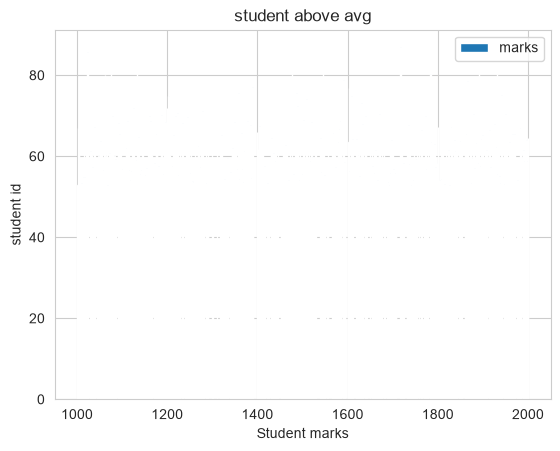

In [94]:
avg=np.average(student['marks'])
# print(avg)
student['above_avg']=student[student['marks']>avg]['marks']
plt.bar(student['student_id'],student['above_avg'],label='marks')
plt.title('student above avg')
plt.xlabel('Student marks')
plt.ylabel('student id')
plt.legend()

#### Does study time affect marks?

In [95]:
student.head()

,student_id,age,gender,study_time,attendance,parental_education,internet_access,previous_marks,marks,final_result,above_avg
0,1001,19,Male,4.6,76.5,Diploma,Yes,73.7,53.0,Pass,53.0
1,1002,22,Female,4.0,78.4,Diploma,Yes,71.5,46.3,Pass,NaN
2,1003,20,Female,4.1,86.5,Master's,Yes,81.2,67.0,Pass,67.0
3,1004,19,Female,1.4,82.8,Diploma,Yes,68.4,44.0,Pass,NaN
4,1005,18,Female,4.8,75.8,Diploma,Yes,76.2,72.3,Pass,72.3


Text(0, 0.5, 'study time')

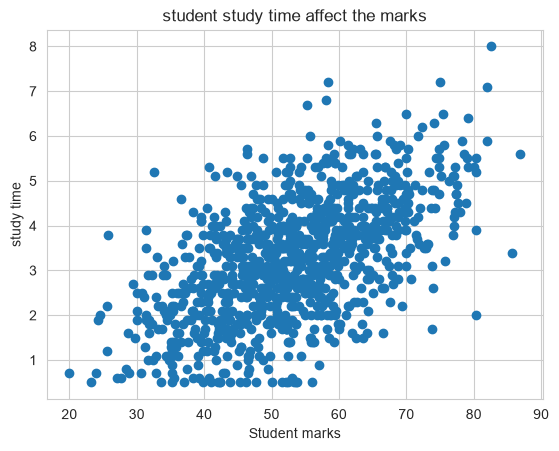

In [96]:
plt.scatter(student['marks'],student['study_time'])
plt.title('student study time affect the marks')
plt.xlabel('Student marks')
plt.ylabel('study time')


<Axes: xlabel='study_time', ylabel='marks'>

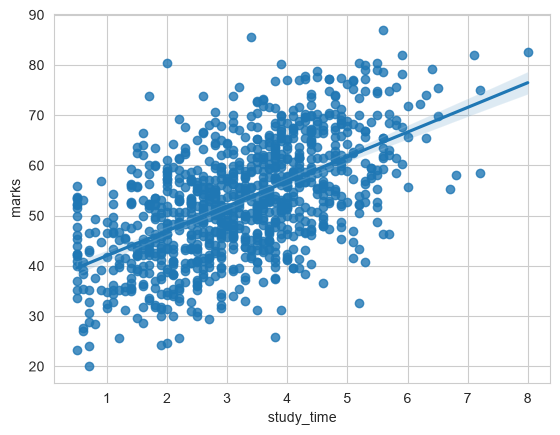

In [97]:
sns.regplot(
    data=student,
    x='study_time',
    y='marks'
)

#### Does attendance affect performance?

In [98]:
student.head()

,student_id,age,gender,study_time,attendance,parental_education,internet_access,previous_marks,marks,final_result,above_avg
0,1001,19,Male,4.6,76.5,Diploma,Yes,73.7,53.0,Pass,53.0
1,1002,22,Female,4.0,78.4,Diploma,Yes,71.5,46.3,Pass,NaN
2,1003,20,Female,4.1,86.5,Master's,Yes,81.2,67.0,Pass,67.0
3,1004,19,Female,1.4,82.8,Diploma,Yes,68.4,44.0,Pass,NaN
4,1005,18,Female,4.8,75.8,Diploma,Yes,76.2,72.3,Pass,72.3


<Axes: xlabel='attendance', ylabel='marks'>

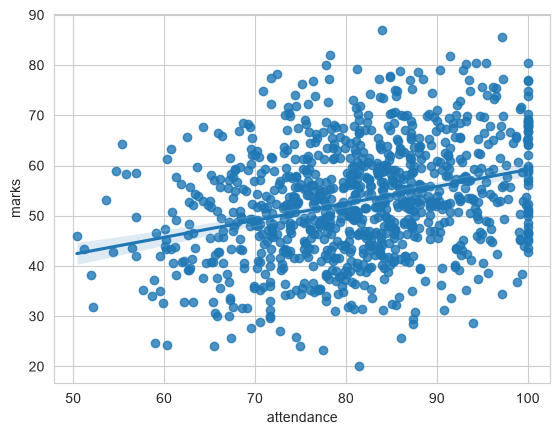

In [99]:
sns.regplot(data=student,x='attendance',y='marks')

#### Which subject has the highest average?

In [100]:
student.head()
student['parental_education'].value_counts()

parental_education
Bachelor's     332
High School    210
Master's       206
Diploma        183
PhD             59
Name: count, dtype: int64

Text(0, 0.5, 'Avg_marks')

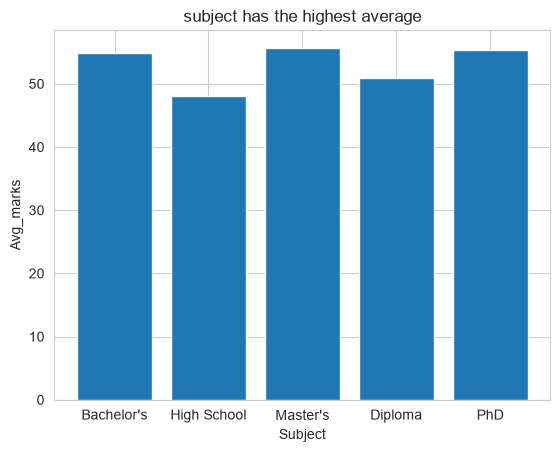

In [101]:
sns.set_style('whitegrid')
Diploma=np.average(student[student['parental_education']=='Diploma']['marks'])
Masters=np.average(student[student['parental_education']=="Master's"]['marks'])
bachelor=np.average(student[student['parental_education']=="Bachelor's"]['marks'])
highschool=np.average(student[student['parental_education']=="High School"]['marks'])
phd=np.average(student[student['parental_education']=="PhD"]['marks'])
subject=["Bachelor's","High School","Master's","Diploma","PhD"]
avg_marks=[bachelor,highschool,Masters,Diploma,phd]
plt.bar(subject,avg_marks)
plt.title('subject has the highest average')
plt.xlabel('Subject')
plt.ylabel('Avg_marks')


#### Are there outliers?

<Axes: ylabel='marks'>

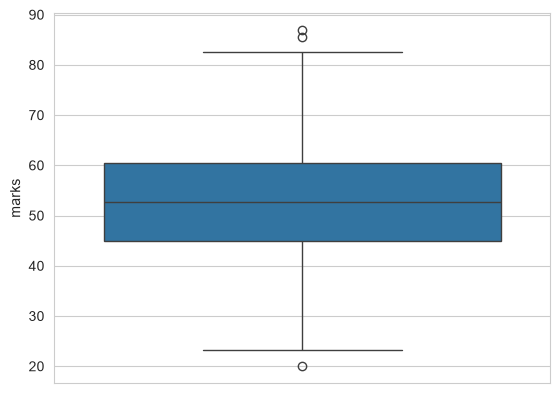

In [102]:
sns.boxplot(data=student,y='marks')

<Axes: ylabel='marks'>

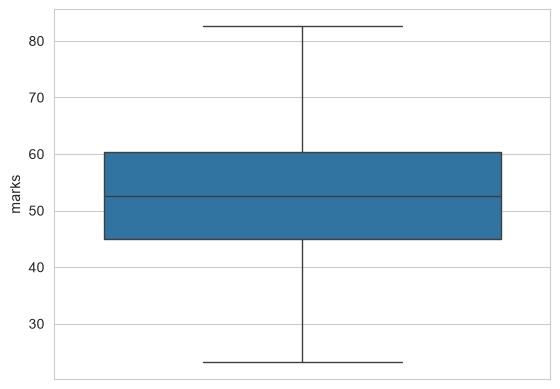

In [103]:
Q1=student['marks'].quantile(0.25)
Q3=student['marks'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
student_clean=student[
    (student['marks']>=lower) &
    (student['marks']<=upper)
]
sns.boxplot(data=student_clean,y='marks')

# Titanic EDA -- project 2

#### What percentage survived?

In [104]:
titanic=pd.read_csv('./titanic_data.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,"White, Albert",male,1.7,0,0,22.69,C
1,2,0,3,"Williams, Dorothy",female,20.2,0,0,23.52,Q
2,3,0,2,"Jones, Dorothy",female,17.5,0,1,28.84,S
3,4,0,3,"Davis, John",male,31.3,0,2,24.55,Q
4,5,0,3,"Miller, Charles",male,30.5,1,1,44.89,S


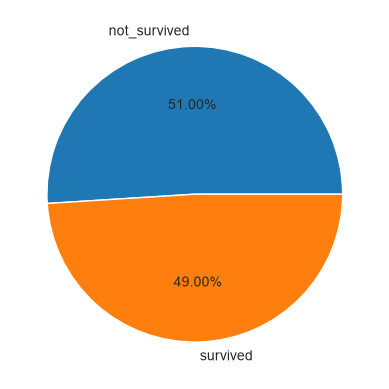

In [105]:
survived_zero=titanic[titanic['Survived']==0].shape[0]
survived_one=titanic[titanic['Survived']==1].shape[0]
labels=['not_survived','survived']
plt.pie([survived_zero,survived_one],labels=labels,autopct='%1.2f%%')

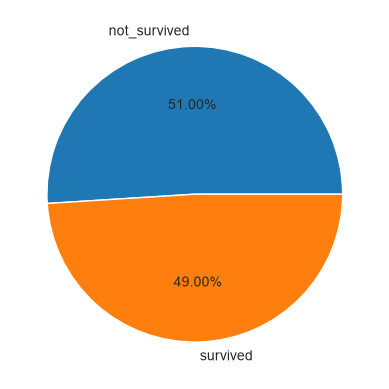

In [106]:
labels=['not_survived','survived']
sur=titanic.groupby('Survived')['Survived'].value_counts()
plt.pie(sur,labels=labels,autopct='%1.2f%%')


#### Did females have higher survival rates?

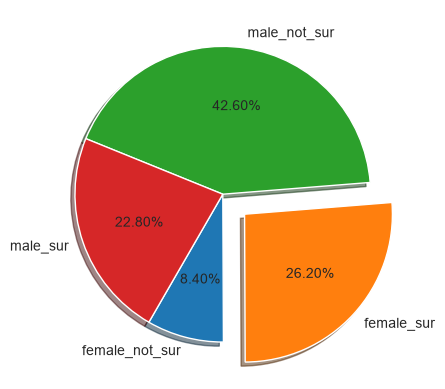

In [107]:
fem_sur=titanic.groupby(['Sex','Survived'])['Survived'].value_counts()
labels=['female_not_sur','female_sur','male_not_sur','male_sur']
plt.pie(fem_sur,labels=labels,autopct='%1.2f%%',explode=[0,0.2,0,0],shadow='True',startangle=240)

<Axes: xlabel='Sex', ylabel='Survived'>

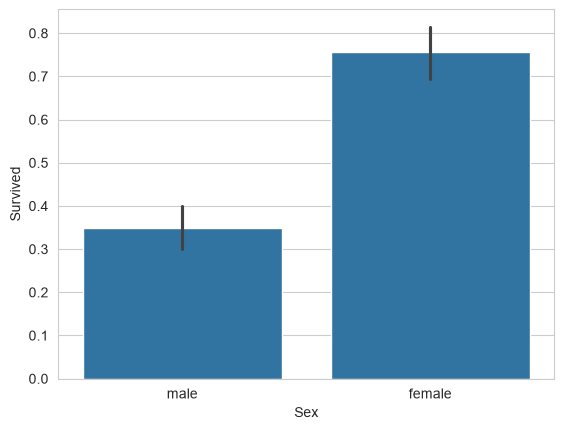

In [108]:
sns.barplot(data=titanic,x='Sex',y='Survived')

#### Did passenger class affect survival?

<Axes: xlabel='Pclass', ylabel='Survived'>

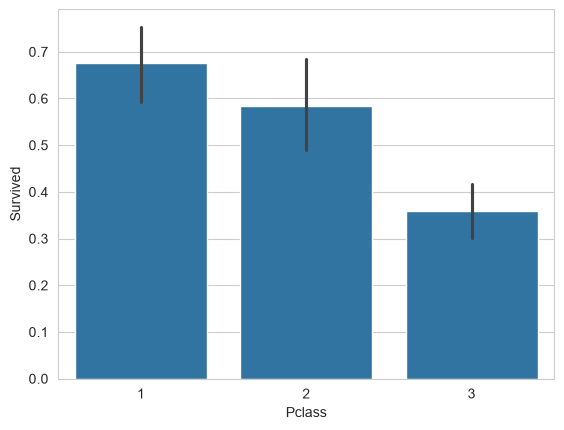

In [109]:
sns.barplot(
    data=titanic,
    x='Pclass',
    y='Survived'
)

#### What was the age distribution?

<Axes: xlabel='Age', ylabel='Count'>

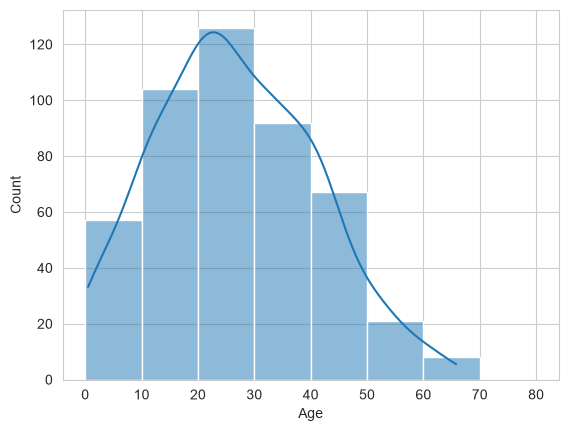

In [110]:
titanic.head()
bins=[0,10,20,30,40,50,60,70,80]
sns.histplot(data=titanic,x='Age',bins=bins,kde=True)

#### Which factors appear associated with survival?

In [111]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,"White, Albert",male,1.7,0,0,22.69,C
1,2,0,3,"Williams, Dorothy",female,20.2,0,0,23.52,Q
2,3,0,2,"Jones, Dorothy",female,17.5,0,1,28.84,S
3,4,0,3,"Davis, John",male,31.3,0,2,24.55,Q
4,5,0,3,"Miller, Charles",male,30.5,1,1,44.89,S


<Axes: xlabel='Survived', ylabel='Fare'>

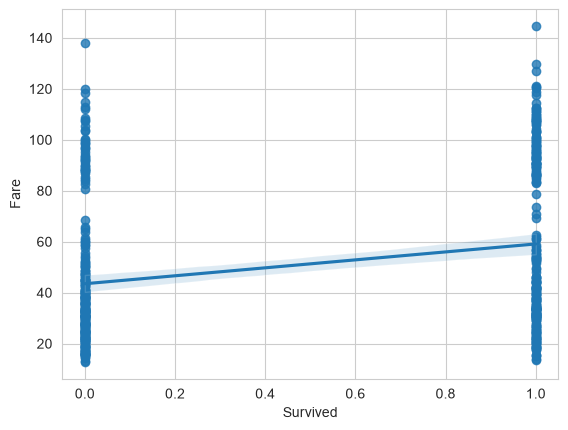

In [112]:
sns.regplot(data=titanic,y='Fare',x='Survived')


<Axes: >

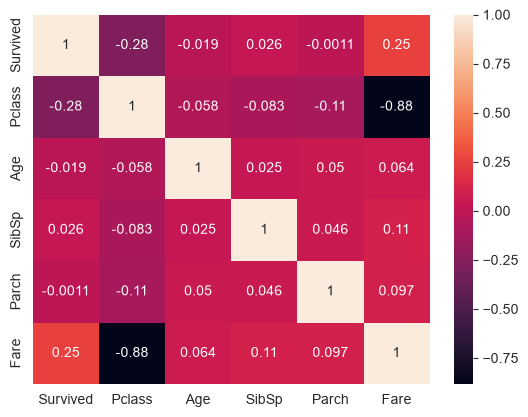

In [113]:
columns=['Survived','Pclass','Age','SibSp','Parch','Fare']
sns.heatmap(data=titanic[columns].corr(),annot=True)

#### Are there missing values?

In [114]:
missing=titanic.isnull().sum()
print(missing)

PassengerId     0
Survived        0
Pclass          0
Name            0
Sex             0
Age            25
SibSp           0
Parch           0
Fare            0
Embarked        8
dtype: int64


Text(0.5, 1.0, 'no.of.null_value in table')

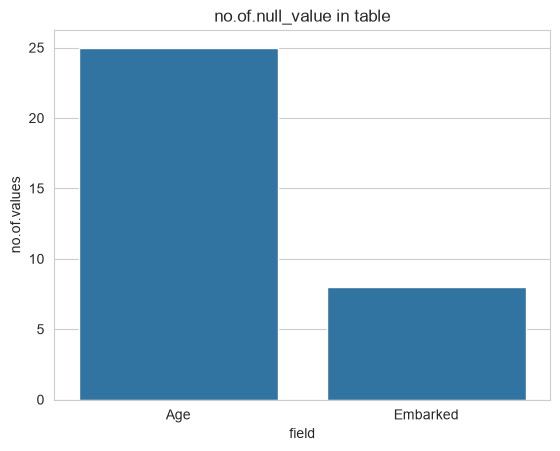

In [115]:
missing=titanic.isnull().sum()
missing = missing[missing > 0]
sns.barplot(x=missing.index,y=missing.values)
plt.xlabel('field')
plt.ylabel('no.of.values')
plt.title('no.of.null_value in table')

#### Are there outliers?

<Axes: >

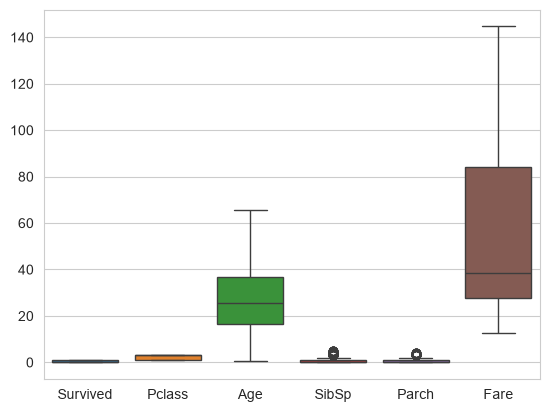

In [116]:
columns=['Survived','Pclass','Age','SibSp','Parch','Fare']
sns.boxplot(data=titanic[columns])

<Axes: ylabel='Parch'>

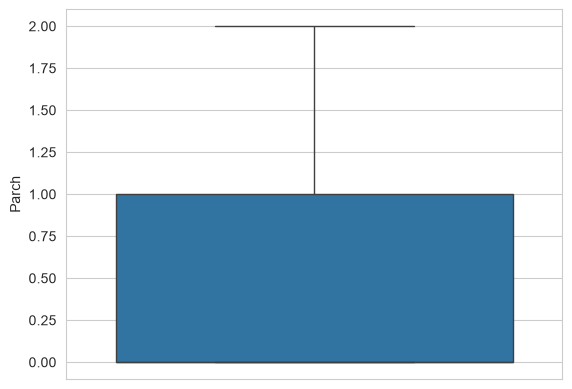

In [117]:
Q1=titanic['Parch'].quantile(0.25)
Q3=titanic['Parch'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
remove_outlier=titanic[
    (titanic['Parch']>=lower)&
    (titanic['Parch']<=upper)
]
sns.boxplot(data=remove_outlier,y='Parch')

# Netflix Movies & TV Shows -- project 3

#### How many Movies vs TV Shows are there?

In [118]:
movies=pd.read_csv('movies.csv')
movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s0001,Movie,One More Day,Liam Miller,James Kumar,United States,"August 31, 2023",1996,TV-PG,146 min,"Comedy, British TV Shows","A powerful story exploring relationships, iden..."
1,s0002,Movie,One More Day 2013,Olivia Wilson,Alex Miller,United States,NaN,2018,TV-MA,134 min,Documentaries,"An ambitious journey filled with mystery, humo..."
2,s0003,TV Show,Hidden Lives,NaN,"Emily Garcia, Daniel Jones, Maya Miller",Italy,"May 13, 2020",2002,TV-G,5 Seasons,"Crime TV Shows, Comedy, Thrillers","An ambitious journey filled with mystery, humo..."
3,s0004,TV Show,City Stories,NaN,Arjun Sharma,"India, South Korea",NaN,2001,TV-MA,3 Seasons,"Anime Series, British TV Shows","A compelling story about friendship, family, a..."
4,s0005,Movie,Midnight Streets,NaN,"James Kumar, Robert Smith, Emma Kumar, Maya An...","France, Australia","May 14, 2023",2022,R,127 min,"Drama, Horror Movies",A young protagonist must overcome difficult ch...


<Axes: xlabel='type', ylabel='count'>

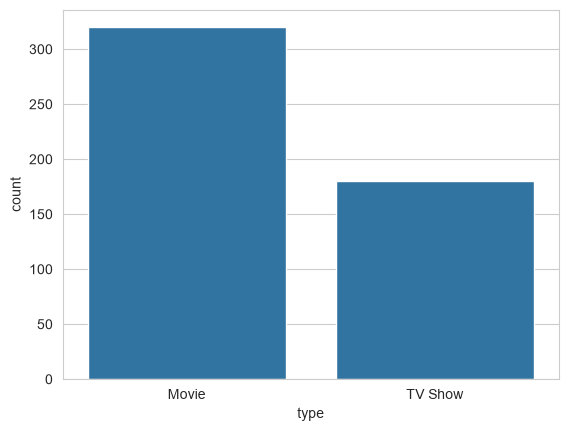

In [119]:
sns.countplot(data=movies,x='type')

#### Which year had the most releases?

2018


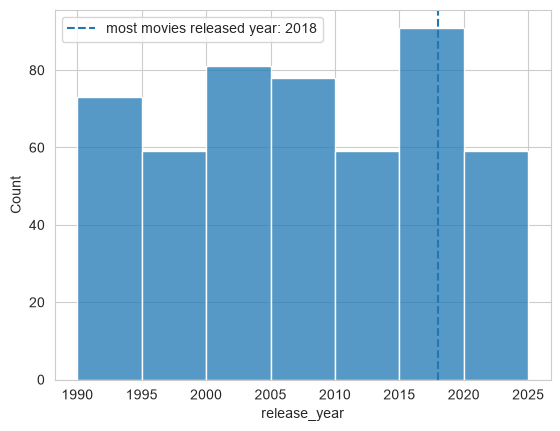

In [120]:
most_release=movies['release_year'].value_counts().idxmax()
print(most_release)
bins=[1990,1995,2000,2005,2010,2015,2020,2025]
sns.histplot(data=movies,x='release_year',bins=bins)
plt.axvline(most_release,linestyle='--',label=f'most movies released year: {most_release}')
plt.legend()


#### Which countries produce the most content?

In [121]:
movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s0001,Movie,One More Day,Liam Miller,James Kumar,United States,"August 31, 2023",1996,TV-PG,146 min,"Comedy, British TV Shows","A powerful story exploring relationships, iden..."
1,s0002,Movie,One More Day 2013,Olivia Wilson,Alex Miller,United States,NaN,2018,TV-MA,134 min,Documentaries,"An ambitious journey filled with mystery, humo..."
2,s0003,TV Show,Hidden Lives,NaN,"Emily Garcia, Daniel Jones, Maya Miller",Italy,"May 13, 2020",2002,TV-G,5 Seasons,"Crime TV Shows, Comedy, Thrillers","An ambitious journey filled with mystery, humo..."
3,s0004,TV Show,City Stories,NaN,Arjun Sharma,"India, South Korea",NaN,2001,TV-MA,3 Seasons,"Anime Series, British TV Shows","A compelling story about friendship, family, a..."
4,s0005,Movie,Midnight Streets,NaN,"James Kumar, Robert Smith, Emma Kumar, Maya An...","France, Australia","May 14, 2023",2022,R,127 min,"Drama, Horror Movies",A young protagonist must overcome difficult ch...


<Axes: ylabel='c'>

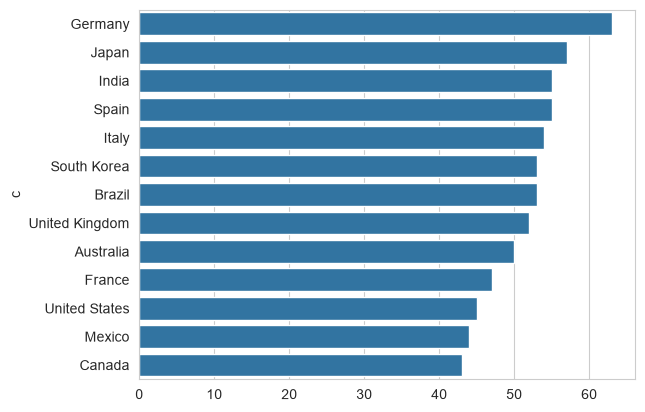

In [122]:
movies['c']=movies['country'].str.split(',')
country = movies['c'].explode()
country=country.str.strip()
count=country.value_counts()
sns.barplot(y=count.index,x=count.values)

In [123]:
valid_country=movies['country'].notna()
valid=movies[valid_country ]
valid['country']=valid['country'].str.split(',')
valid = valid.explode('country')
valid.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,c
0,s0001,Movie,One More Day,Liam Miller,James Kumar,United States,"August 31, 2023",1996,TV-PG,146 min,"Comedy, British TV Shows","A powerful story exploring relationships, iden...",[United States]
1,s0002,Movie,One More Day 2013,Olivia Wilson,Alex Miller,United States,NaN,2018,TV-MA,134 min,Documentaries,"An ambitious journey filled with mystery, humo...",[United States]
2,s0003,TV Show,Hidden Lives,NaN,"Emily Garcia, Daniel Jones, Maya Miller",Italy,"May 13, 2020",2002,TV-G,5 Seasons,"Crime TV Shows, Comedy, Thrillers","An ambitious journey filled with mystery, humo...",[Italy]
3,s0004,TV Show,City Stories,NaN,Arjun Sharma,India,NaN,2001,TV-MA,3 Seasons,"Anime Series, British TV Shows","A compelling story about friendship, family, a...","[India, South Korea]"
3,s0004,TV Show,City Stories,NaN,Arjun Sharma,South Korea,NaN,2001,TV-MA,3 Seasons,"Anime Series, British TV Shows","A compelling story about friendship, family, a...","[India, South Korea]"
4,s0005,Movie,Midnight Streets,NaN,"James Kumar, Robert Smith, Emma Kumar, Maya An...",France,"May 14, 2023",2022,R,127 min,"Drama, Horror Movies",A young protagonist must overcome difficult ch...,"[France, Australia]"
4,s0005,Movie,Midnight Streets,NaN,"James Kumar, Robert Smith, Emma Kumar, Maya An...",Australia,"May 14, 2023",2022,R,127 min,"Drama, Horror Movies",A young protagonist must overcome difficult ch...,"[France, Australia]"
5,s0006,Movie,The Last Horizon,Olivia Jones,Isabella Garcia,Germany,"February 02, 2019",2019,TV-14,122 min,Romantic Movies,A young protagonist must overcome difficult ch...,[Germany]
6,s0007,Movie,The Secret Garden,David Martin,NaN,France,"February 23, 2026",2010,TV-14,104 min,Comedy,A group of strangers discovers a secret that c...,"[France, Australia]"
6,s0007,Movie,The Secret Garden,David Martin,NaN,Australia,"February 23, 2026",2010,TV-14,104 min,Comedy,A group of strangers discovers a secret that c...,"[France, Australia]"


#### What is the distribution of content ratings?

In [124]:
movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,c
0,s0001,Movie,One More Day,Liam Miller,James Kumar,United States,"August 31, 2023",1996,TV-PG,146 min,"Comedy, British TV Shows","A powerful story exploring relationships, iden...",[United States]
1,s0002,Movie,One More Day 2013,Olivia Wilson,Alex Miller,United States,NaN,2018,TV-MA,134 min,Documentaries,"An ambitious journey filled with mystery, humo...",[United States]
2,s0003,TV Show,Hidden Lives,NaN,"Emily Garcia, Daniel Jones, Maya Miller",Italy,"May 13, 2020",2002,TV-G,5 Seasons,"Crime TV Shows, Comedy, Thrillers","An ambitious journey filled with mystery, humo...",[Italy]
3,s0004,TV Show,City Stories,NaN,Arjun Sharma,"India, South Korea",NaN,2001,TV-MA,3 Seasons,"Anime Series, British TV Shows","A compelling story about friendship, family, a...","[India, South Korea]"
4,s0005,Movie,Midnight Streets,NaN,"James Kumar, Robert Smith, Emma Kumar, Maya An...","France, Australia","May 14, 2023",2022,R,127 min,"Drama, Horror Movies",A young protagonist must overcome difficult ch...,"[France, Australia]"


<Axes: xlabel='rating'>

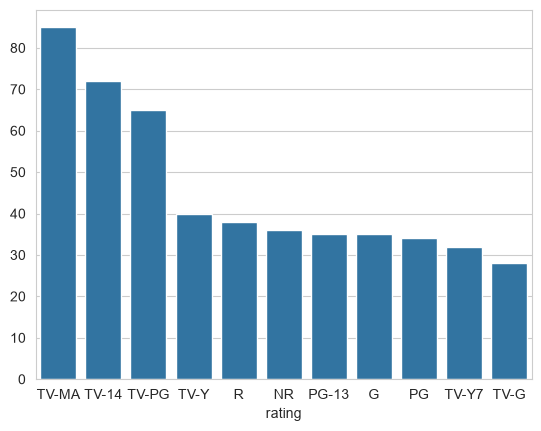

In [125]:
dis=movies['rating'].value_counts()
sns.barplot(x=dis.index,y=dis.values)

#### How has Netflix content changed over the years?

In [126]:
movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,c
0,s0001,Movie,One More Day,Liam Miller,James Kumar,United States,"August 31, 2023",1996,TV-PG,146 min,"Comedy, British TV Shows","A powerful story exploring relationships, iden...",[United States]
1,s0002,Movie,One More Day 2013,Olivia Wilson,Alex Miller,United States,NaN,2018,TV-MA,134 min,Documentaries,"An ambitious journey filled with mystery, humo...",[United States]
2,s0003,TV Show,Hidden Lives,NaN,"Emily Garcia, Daniel Jones, Maya Miller",Italy,"May 13, 2020",2002,TV-G,5 Seasons,"Crime TV Shows, Comedy, Thrillers","An ambitious journey filled with mystery, humo...",[Italy]
3,s0004,TV Show,City Stories,NaN,Arjun Sharma,"India, South Korea",NaN,2001,TV-MA,3 Seasons,"Anime Series, British TV Shows","A compelling story about friendship, family, a...","[India, South Korea]"
4,s0005,Movie,Midnight Streets,NaN,"James Kumar, Robert Smith, Emma Kumar, Maya An...","France, Australia","May 14, 2023",2022,R,127 min,"Drama, Horror Movies",A young protagonist must overcome difficult ch...,"[France, Australia]"


<Axes: xlabel='release_year'>

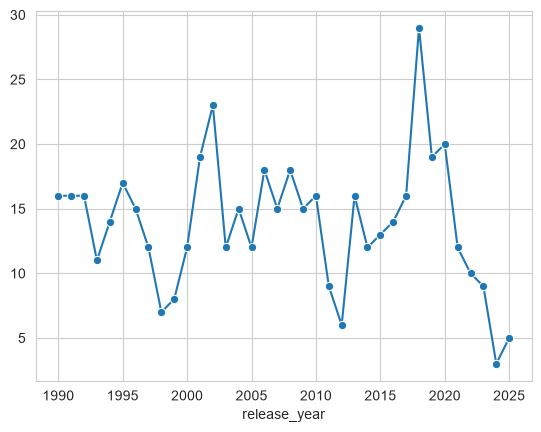

In [127]:
year_count=movies['release_year'].value_counts().sort_index()
sns.lineplot(
    x=year_count.index,
    y=year_count.values,
    marker='o'
)

    release_year     type  count
0           1990    Movie     10
1           1990  TV Show      6
2           1991    Movie     11
3           1991  TV Show      5
4           1992    Movie      9
..           ...      ...    ...
67          2023  TV Show      3
68          2024    Movie      2
69          2024  TV Show      1
70          2025    Movie      2
71          2025  TV Show      3

[72 rows x 3 columns]


<Axes: xlabel='release_year', ylabel='count'>

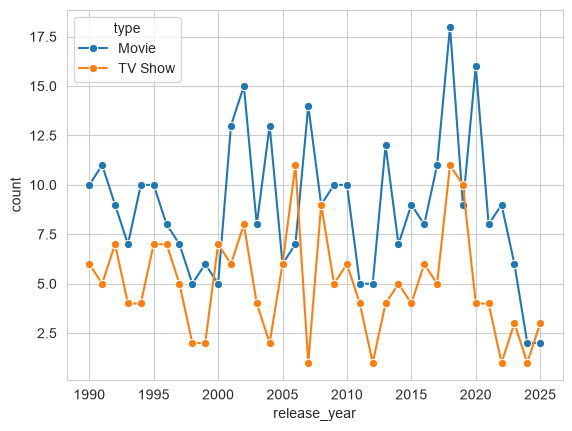

In [128]:
#trend=pd.DataFrame(movies.groupby(['release_year','type'])['release_year'].value_counts().sort_index())
trend=pd.DataFrame(movies.groupby(['release_year','type']).size().sort_index().reset_index(name='count'))
print(trend)
sns.lineplot(data=trend,x='release_year',y='count',hue='type',marker='o')

#### Which type has the longest duration?

In [129]:
movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,c
0,s0001,Movie,One More Day,Liam Miller,James Kumar,United States,"August 31, 2023",1996,TV-PG,146 min,"Comedy, British TV Shows","A powerful story exploring relationships, iden...",[United States]
1,s0002,Movie,One More Day 2013,Olivia Wilson,Alex Miller,United States,NaN,2018,TV-MA,134 min,Documentaries,"An ambitious journey filled with mystery, humo...",[United States]
2,s0003,TV Show,Hidden Lives,NaN,"Emily Garcia, Daniel Jones, Maya Miller",Italy,"May 13, 2020",2002,TV-G,5 Seasons,"Crime TV Shows, Comedy, Thrillers","An ambitious journey filled with mystery, humo...",[Italy]
3,s0004,TV Show,City Stories,NaN,Arjun Sharma,"India, South Korea",NaN,2001,TV-MA,3 Seasons,"Anime Series, British TV Shows","A compelling story about friendship, family, a...","[India, South Korea]"
4,s0005,Movie,Midnight Streets,NaN,"James Kumar, Robert Smith, Emma Kumar, Maya An...","France, Australia","May 14, 2023",2022,R,127 min,"Drama, Horror Movies",A young protagonist must overcome difficult ch...,"[France, Australia]"


In [130]:
type_movies=movies[movies['type']=='Movie']
type_movies['duration']=type_movies['duration'].str.strip('min')
type_movies['duration']=type_movies['duration'].astype('int')
type_movies['duration'].max()

np.int64(180)

#### Are there missing values?

In [131]:
movies.isnull().sum()

show_id           0
type              0
title             0
director        227
cast             52
country          30
date_added       22
release_year      0
rating            0
duration          0
listed_in         0
description       0
c                30
dtype: int64

In [132]:
sample=movies.dropna().copy()
sample.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
c               0
dtype: int64

#### Are there duplicate titles?

In [133]:
dup=movies['title'].value_counts().sort_values()
dup[dup>1]


title
Hidden Lives 2016         2
The Last Horizon 2017     2
The Detectives 2011       2
Kitchen Stories           2
Hidden Lives              3
Code Breakers             4
Inside the Case           4
The Travelers             4
Beyond Borders            5
The Next Chapter          5
Unknown Files             6
Life in Mumbai            6
The Detectives            6
Worlds Apart              7
The New Generation        8
Echoes of Tomorrow        8
City Stories              8
After Midnight            9
Hidden Truth              9
Lost in Time              9
Daily Dose                9
The Final Journey        10
Into the Wild            10
The Academy              10
The Last Horizon         10
The Secret Garden        10
The Last Kingdom         10
Midnight Streets         12
Modern Families          13
The Great Escape         13
Broken Promises          13
City of Shadows          14
The Silent House         14
Beyond the River         15
The Family House         15
A Second Chanc

In [134]:
movies['title'].duplicated().sum()

np.int64(381)

In [135]:
movies['title'].duplicated().any()

np.True_

#### Which directors have the most titles?

In [136]:
movies.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,c
0,s0001,Movie,One More Day,Liam Miller,James Kumar,United States,"August 31, 2023",1996,TV-PG,146 min,"Comedy, British TV Shows","A powerful story exploring relationships, iden...",[United States]
1,s0002,Movie,One More Day 2013,Olivia Wilson,Alex Miller,United States,NaN,2018,TV-MA,134 min,Documentaries,"An ambitious journey filled with mystery, humo...",[United States]
2,s0003,TV Show,Hidden Lives,NaN,"Emily Garcia, Daniel Jones, Maya Miller",Italy,"May 13, 2020",2002,TV-G,5 Seasons,"Crime TV Shows, Comedy, Thrillers","An ambitious journey filled with mystery, humo...",[Italy]
3,s0004,TV Show,City Stories,NaN,Arjun Sharma,"India, South Korea",NaN,2001,TV-MA,3 Seasons,"Anime Series, British TV Shows","A compelling story about friendship, family, a...","[India, South Korea]"
4,s0005,Movie,Midnight Streets,NaN,"James Kumar, Robert Smith, Emma Kumar, Maya An...","France, Australia","May 14, 2023",2022,R,127 min,"Drama, Horror Movies",A young protagonist must overcome difficult ch...,"[France, Australia]"


In [137]:
movies.isnull().sum()

show_id           0
type              0
title             0
director        227
cast             52
country          30
date_added       22
release_year      0
rating            0
duration          0
listed_in         0
description       0
c                30
dtype: int64

In [138]:
most_title= movies['director'].value_counts().reset_index(name='count')
most_count= movies['director'].value_counts().max()
most_title=most_title[most_title['count']==most_count]

#### What percentage of Netflix content is Movies vs TV Shows?

In [139]:
movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,c
0,s0001,Movie,One More Day,Liam Miller,James Kumar,United States,"August 31, 2023",1996,TV-PG,146 min,"Comedy, British TV Shows","A powerful story exploring relationships, iden...",[United States]
1,s0002,Movie,One More Day 2013,Olivia Wilson,Alex Miller,United States,NaN,2018,TV-MA,134 min,Documentaries,"An ambitious journey filled with mystery, humo...",[United States]
2,s0003,TV Show,Hidden Lives,NaN,"Emily Garcia, Daniel Jones, Maya Miller",Italy,"May 13, 2020",2002,TV-G,5 Seasons,"Crime TV Shows, Comedy, Thrillers","An ambitious journey filled with mystery, humo...",[Italy]
3,s0004,TV Show,City Stories,NaN,Arjun Sharma,"India, South Korea",NaN,2001,TV-MA,3 Seasons,"Anime Series, British TV Shows","A compelling story about friendship, family, a...","[India, South Korea]"
4,s0005,Movie,Midnight Streets,NaN,"James Kumar, Robert Smith, Emma Kumar, Maya An...","France, Australia","May 14, 2023",2022,R,127 min,"Drama, Horror Movies",A young protagonist must overcome difficult ch...,"[France, Australia]"


c:\Users\Mowneesh\OneDrive\Desktop\Leaning_ml\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\Mowneesh\OneDrive\Desktop\Leaning_ml\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


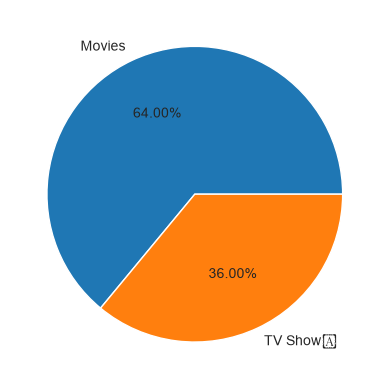

In [140]:
plt.pie(movies['type'].value_counts(),labels=['Movies','TV Show	'],autopct='%1.2f%%')

<Axes: xlabel='type'>

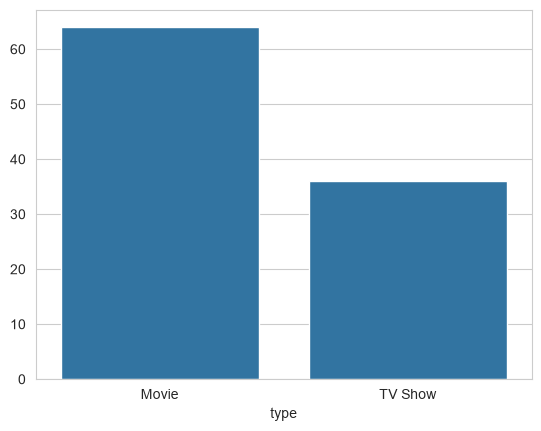

In [141]:
movies_count=movies['type'].value_counts(normalize=True)*100
sns.barplot(x=movies_count.index,y=movies_count.values)
# normalize means eg= 360/500 = 0.6
                    # 140/500 =0.4

# Sales Data Analysis

#### What is the total sales?

In [142]:
sales=pd.read_csv('sales_data.csv')
sales.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Region,State,City,Product_Category,Product,Quantity,Unit_Price,Discount,Sales,Payment_Method,Order_Status,Salesperson
0,ORD00001,2025-01-07,CUST0100,Sneha Das,Female,19.0,South,Kerala,Kochi,Electronics,Tablet,3,17844.00,0,53532.00,Debit Card,Delivered,Divya Sharma
1,ORD00002,2025-11-12,CUST0188,Pooja Patel,Male,20.0,South,Kerala,Kochi,Clothing,Jeans,3,1582.58,5,4510.35,Cash,Delivered,Vijay Reddy
2,ORD00003,2024-04-01,CUST0264,Naveen Patel,Female,53.0,West,Maharashtra,Pune,Groceries,Coffee,3,441.75,0,1325.25,UPI,Delivered,Ananya Sharma
3,ORD00004,2024-09-26,CUST0271,Sneha Iyer,Female,57.0,West,Maharashtra,Pune,Clothing,Dress,8,2296.85,20,0.00,Cash,Cancelled,Suresh Sharma
4,ORD00005,2025-06-04,CUST0129,Neha Das,Male,28.0,West,Goa,Panaji,Furniture,Sofa,3,26996.48,5,76939.97,UPI,Delivered,Sneha Patel


In [143]:
sales['Sales'].sum()

np.float64(27716460.779999997)

#### What is the average order value?

In [144]:
avg=sales['Sales'].mean()
avg

np.float64(27716.460779999998)

#### Which product category has the highest sales?

In [145]:
sales.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Region,State,City,Product_Category,Product,Quantity,Unit_Price,Discount,Sales,Payment_Method,Order_Status,Salesperson
0,ORD00001,2025-01-07,CUST0100,Sneha Das,Female,19.0,South,Kerala,Kochi,Electronics,Tablet,3,17844.00,0,53532.00,Debit Card,Delivered,Divya Sharma
1,ORD00002,2025-11-12,CUST0188,Pooja Patel,Male,20.0,South,Kerala,Kochi,Clothing,Jeans,3,1582.58,5,4510.35,Cash,Delivered,Vijay Reddy
2,ORD00003,2024-04-01,CUST0264,Naveen Patel,Female,53.0,West,Maharashtra,Pune,Groceries,Coffee,3,441.75,0,1325.25,UPI,Delivered,Ananya Sharma
3,ORD00004,2024-09-26,CUST0271,Sneha Iyer,Female,57.0,West,Maharashtra,Pune,Clothing,Dress,8,2296.85,20,0.00,Cash,Cancelled,Suresh Sharma
4,ORD00005,2025-06-04,CUST0129,Neha Das,Male,28.0,West,Goa,Panaji,Furniture,Sofa,3,26996.48,5,76939.97,UPI,Delivered,Sneha Patel


Product_Category
Clothing            1087879.12
Electronics        13841999.20
Furniture           8679672.98
Groceries            128884.22
Home Appliances     3978025.26
Name: Sales, dtype: float64
Electronics
13841999.2


<Axes: xlabel='Product_Category'>

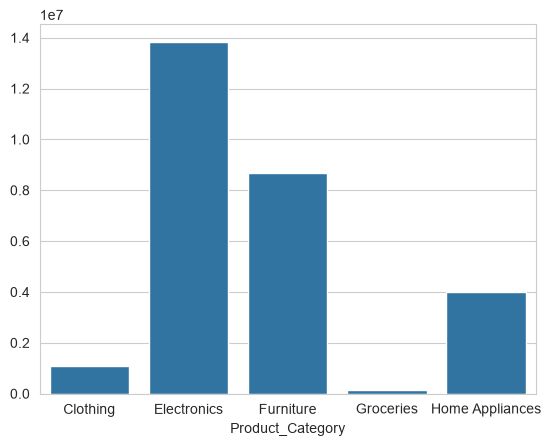

In [146]:
category_sales=sales.groupby('Product_Category')['Sales'].sum()
most_product=category_sales.idxmax()
most_product_count=category_sales.max()
print(category_sales)
print(most_product)
print(most_product_count)
sns.barplot(x=category_sales.index,y=category_sales.values)

#### Which product sells the most?

Product_Category
Clothing           644
Electronics        807
Furniture          647
Groceries          458
Home Appliances    573
Name: Quantity, dtype: int64
Electronics
807


<Axes: xlabel='Product_Category'>

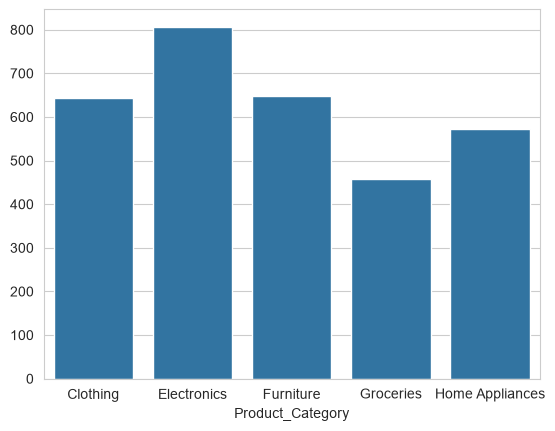

In [147]:
category_sales_units=sales.groupby('Product_Category')['Quantity'].sum()
most_category_sales=category_sales_units.idxmax()
most_category_count=category_sales_units.max()
print(category_sales_units)
print(most_category_sales)
print(most_category_count)
sns.barplot(x=category_sales_units.index,y=category_sales_units.values)

#### Which region generates the most sales?

In [148]:
sales.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Region,State,City,Product_Category,Product,Quantity,Unit_Price,Discount,Sales,Payment_Method,Order_Status,Salesperson
0,ORD00001,2025-01-07,CUST0100,Sneha Das,Female,19.0,South,Kerala,Kochi,Electronics,Tablet,3,17844.00,0,53532.00,Debit Card,Delivered,Divya Sharma
1,ORD00002,2025-11-12,CUST0188,Pooja Patel,Male,20.0,South,Kerala,Kochi,Clothing,Jeans,3,1582.58,5,4510.35,Cash,Delivered,Vijay Reddy
2,ORD00003,2024-04-01,CUST0264,Naveen Patel,Female,53.0,West,Maharashtra,Pune,Groceries,Coffee,3,441.75,0,1325.25,UPI,Delivered,Ananya Sharma
3,ORD00004,2024-09-26,CUST0271,Sneha Iyer,Female,57.0,West,Maharashtra,Pune,Clothing,Dress,8,2296.85,20,0.00,Cash,Cancelled,Suresh Sharma
4,ORD00005,2025-06-04,CUST0129,Neha Das,Male,28.0,West,Goa,Panaji,Furniture,Sofa,3,26996.48,5,76939.97,UPI,Delivered,Sneha Patel


Region
East      3184901.37
North     6510170.52
South    10611915.52
West      7409473.37
Name: Sales, dtype: float64
South
10611915.52


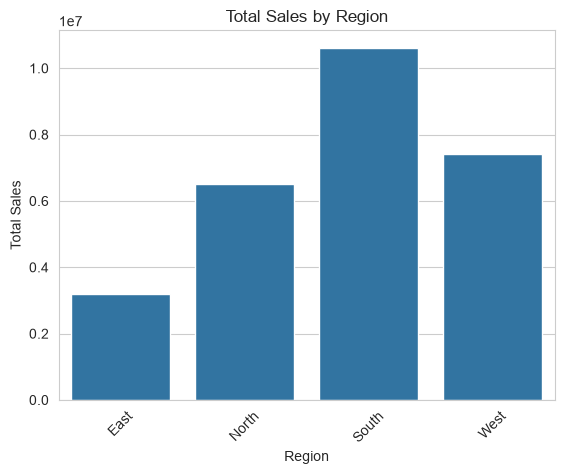

In [149]:
region_sale=sales.groupby('Region')['Sales'].sum()
most_region_sales=region_sale.idxmax()
most_region_count=region_sale.max()
print(region_sale)
print(most_region_sales)
print(most_region_count)
sns.barplot(
    x=region_sale.index,
    y=region_sale.values
)

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

#### Which city has the highest sales?

In [150]:
sales.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Region,State,City,Product_Category,Product,Quantity,Unit_Price,Discount,Sales,Payment_Method,Order_Status,Salesperson
0,ORD00001,2025-01-07,CUST0100,Sneha Das,Female,19.0,South,Kerala,Kochi,Electronics,Tablet,3,17844.00,0,53532.00,Debit Card,Delivered,Divya Sharma
1,ORD00002,2025-11-12,CUST0188,Pooja Patel,Male,20.0,South,Kerala,Kochi,Clothing,Jeans,3,1582.58,5,4510.35,Cash,Delivered,Vijay Reddy
2,ORD00003,2024-04-01,CUST0264,Naveen Patel,Female,53.0,West,Maharashtra,Pune,Groceries,Coffee,3,441.75,0,1325.25,UPI,Delivered,Ananya Sharma
3,ORD00004,2024-09-26,CUST0271,Sneha Iyer,Female,57.0,West,Maharashtra,Pune,Clothing,Dress,8,2296.85,20,0.00,Cash,Cancelled,Suresh Sharma
4,ORD00005,2025-06-04,CUST0129,Neha Das,Male,28.0,West,Goa,Panaji,Furniture,Sofa,3,26996.48,5,76939.97,UPI,Delivered,Sneha Patel


City
Ahmedabad      1534014.64
Amritsar       1937502.22
Bengaluru      2716063.95
Bhubaneswar     968558.83
Chennai        1426638.73
Coimbatore     1709671.98
Jaipur         1772083.30
Kochi          1440017.45
Kolkata        1389864.56
Lucknow        1631211.36
Madurai        1412086.97
Mumbai         2228081.94
New Delhi      1169373.64
Panaji         1813857.27
Patna           826477.98
Pune           1833519.52
Vijayawada     1907436.44
Name: Sales, dtype: float64
Bengaluru
2716063.95


<Axes: ylabel='City'>

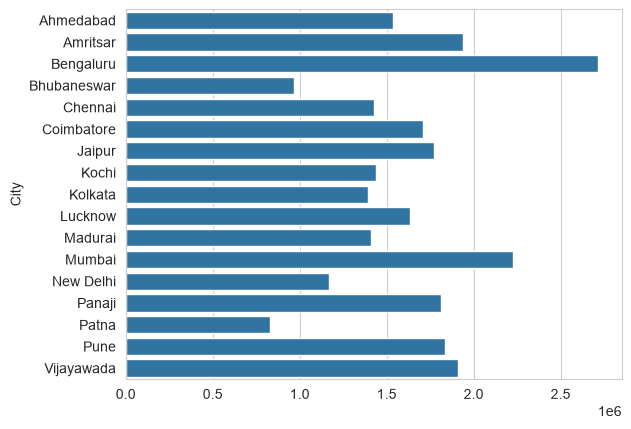

In [151]:
city_sales=sales.groupby('City')['Sales'].sum()
most_city_sales=city_sales.idxmax()
most_city_count=city_sales.max()
print(city_sales)
print(most_city_sales)
print(most_city_count)
sns.barplot(x=city_sales.values,y=city_sales.index)

#### Which month has the highest sales?

In [152]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          1000 non-null   str    
 1   Order_Date        1000 non-null   str    
 2   Customer_ID       1000 non-null   str    
 3   Customer_Name     990 non-null    str    
 4   Gender            1000 non-null   str    
 5   Age               979 non-null    float64
 6   Region            1000 non-null   str    
 7   State             1000 non-null   str    
 8   City              1000 non-null   str    
 9   Product_Category  1000 non-null   str    
 10  Product           1000 non-null   str    
 11  Quantity          1000 non-null   int64  
 12  Unit_Price        1000 non-null   float64
 13  Discount          1000 non-null   int64  
 14  Sales             1000 non-null   float64
 15  Payment_Method    986 non-null    str    
 16  Order_Status      1000 non-null   str    
 17  Salespe

In [153]:
sales['Order_Date']=pd.to_datetime(sales['Order_Date'])
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          1000 non-null   str           
 1   Order_Date        1000 non-null   datetime64[us]
 2   Customer_ID       1000 non-null   str           
 3   Customer_Name     990 non-null    str           
 4   Gender            1000 non-null   str           
 5   Age               979 non-null    float64       
 6   Region            1000 non-null   str           
 7   State             1000 non-null   str           
 8   City              1000 non-null   str           
 9   Product_Category  1000 non-null   str           
 10  Product           1000 non-null   str           
 11  Quantity          1000 non-null   int64         
 12  Unit_Price        1000 non-null   float64       
 13  Discount          1000 non-null   int64         
 14  Sales             1000 non-null   fl

In [154]:
sales['month']=sales['Order_Date'].dt.month
sales.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Region,State,City,Product_Category,Product,Quantity,Unit_Price,Discount,Sales,Payment_Method,Order_Status,Salesperson,month
0,ORD00001,2025-01-07,CUST0100,Sneha Das,Female,19.0,South,Kerala,Kochi,Electronics,Tablet,3,17844.00,0,53532.00,Debit Card,Delivered,Divya Sharma,1
1,ORD00002,2025-11-12,CUST0188,Pooja Patel,Male,20.0,South,Kerala,Kochi,Clothing,Jeans,3,1582.58,5,4510.35,Cash,Delivered,Vijay Reddy,11
2,ORD00003,2024-04-01,CUST0264,Naveen Patel,Female,53.0,West,Maharashtra,Pune,Groceries,Coffee,3,441.75,0,1325.25,UPI,Delivered,Ananya Sharma,4
3,ORD00004,2024-09-26,CUST0271,Sneha Iyer,Female,57.0,West,Maharashtra,Pune,Clothing,Dress,8,2296.85,20,0.00,Cash,Cancelled,Suresh Sharma,9
4,ORD00005,2025-06-04,CUST0129,Neha Das,Male,28.0,West,Goa,Panaji,Furniture,Sofa,3,26996.48,5,76939.97,UPI,Delivered,Sneha Patel,6


month
1     2011831.50
2     1638672.47
3     3496405.29
4     1792115.35
5     2548114.33
6     2637354.68
7     1878441.78
8     2320906.34
9     2188142.38
10    3030864.26
11    2355469.23
12    1818143.17
Name: Sales, dtype: float64
3
3496405.29


<Axes: xlabel='month'>

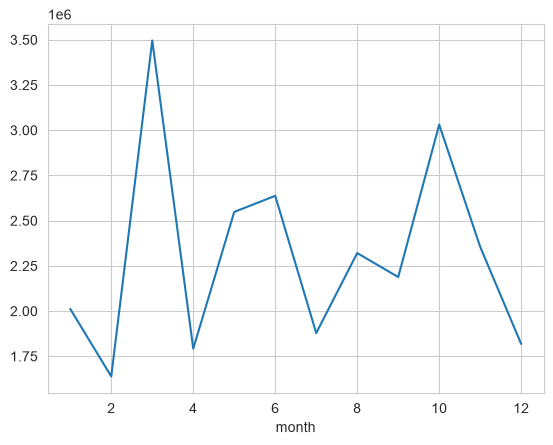

In [155]:
month_sales=sales.groupby('month')['Sales'].sum()
most_month_sales=month_sales.idxmax()
most_month_count=month_sales.max()
print(month_sales)
print(most_month_sales)
print(most_month_count)
sns.lineplot(x=month_sales.index,y=month_sales.values)

#### Does discount affect sales?

In [156]:
sales.head(5)

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Region,State,City,Product_Category,Product,Quantity,Unit_Price,Discount,Sales,Payment_Method,Order_Status,Salesperson,month
0,ORD00001,2025-01-07,CUST0100,Sneha Das,Female,19.0,South,Kerala,Kochi,Electronics,Tablet,3,17844.00,0,53532.00,Debit Card,Delivered,Divya Sharma,1
1,ORD00002,2025-11-12,CUST0188,Pooja Patel,Male,20.0,South,Kerala,Kochi,Clothing,Jeans,3,1582.58,5,4510.35,Cash,Delivered,Vijay Reddy,11
2,ORD00003,2024-04-01,CUST0264,Naveen Patel,Female,53.0,West,Maharashtra,Pune,Groceries,Coffee,3,441.75,0,1325.25,UPI,Delivered,Ananya Sharma,4
3,ORD00004,2024-09-26,CUST0271,Sneha Iyer,Female,57.0,West,Maharashtra,Pune,Clothing,Dress,8,2296.85,20,0.00,Cash,Cancelled,Suresh Sharma,9
4,ORD00005,2025-06-04,CUST0129,Neha Das,Male,28.0,West,Goa,Panaji,Furniture,Sofa,3,26996.48,5,76939.97,UPI,Delivered,Sneha Patel,6


<Axes: xlabel='Sales', ylabel='original_sales'>

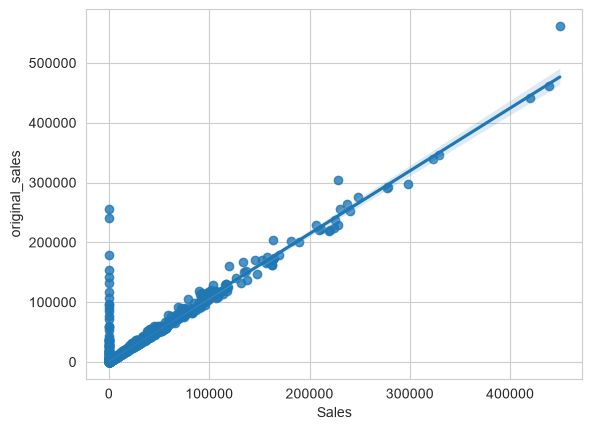

In [157]:
sales['original_sales']=sales['Quantity']*sales['Unit_Price']
sns.regplot(data=sales,x='Sales',y='original_sales')

<Axes: xlabel='Discount', ylabel='Sales'>

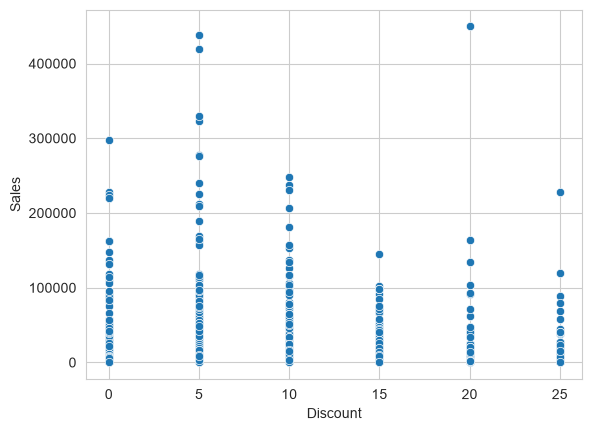

In [158]:
sns.scatterplot(data=sales,x='Discount',y='Sales')

#### Which payment method is most common?

In [159]:
sales.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Region,State,City,Product_Category,Product,Quantity,Unit_Price,Discount,Sales,Payment_Method,Order_Status,Salesperson,month,original_sales
0,ORD00001,2025-01-07,CUST0100,Sneha Das,Female,19.0,South,Kerala,Kochi,Electronics,Tablet,3,17844.00,0,53532.00,Debit Card,Delivered,Divya Sharma,1,53532.00
1,ORD00002,2025-11-12,CUST0188,Pooja Patel,Male,20.0,South,Kerala,Kochi,Clothing,Jeans,3,1582.58,5,4510.35,Cash,Delivered,Vijay Reddy,11,4747.74
2,ORD00003,2024-04-01,CUST0264,Naveen Patel,Female,53.0,West,Maharashtra,Pune,Groceries,Coffee,3,441.75,0,1325.25,UPI,Delivered,Ananya Sharma,4,1325.25
3,ORD00004,2024-09-26,CUST0271,Sneha Iyer,Female,57.0,West,Maharashtra,Pune,Clothing,Dress,8,2296.85,20,0.00,Cash,Cancelled,Suresh Sharma,9,18374.80
4,ORD00005,2025-06-04,CUST0129,Neha Das,Male,28.0,West,Goa,Panaji,Furniture,Sofa,3,26996.48,5,76939.97,UPI,Delivered,Sneha Patel,6,80989.44


Payment_Method
UPI            341
Credit Card    255
Debit Card     201
Net Banking    109
Cash            80
Name: count, dtype: int64
UPI
341


<Axes: xlabel='Payment_Method'>

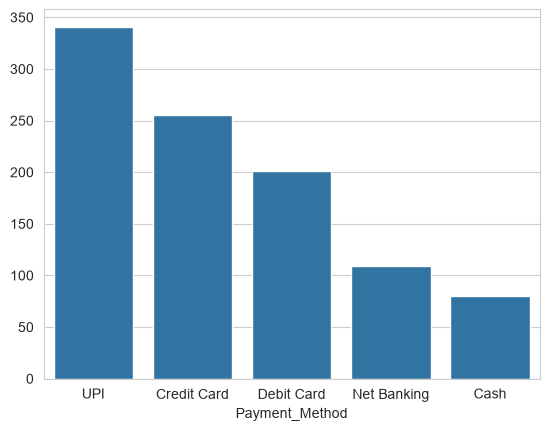

In [160]:
payment_m=sales['Payment_Method'].value_counts()
most_payment_sales=payment_m.idxmax()
most_payment_count=payment_m.max()
print(payment_m)
print(most_payment_sales)
print(most_payment_count)
sns.barplot(x=payment_m.index,y=payment_m.values)

#### What is the distribution of customer ages?

In [161]:
sales.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Region,State,City,Product_Category,Product,Quantity,Unit_Price,Discount,Sales,Payment_Method,Order_Status,Salesperson,month,original_sales
0,ORD00001,2025-01-07,CUST0100,Sneha Das,Female,19.0,South,Kerala,Kochi,Electronics,Tablet,3,17844.00,0,53532.00,Debit Card,Delivered,Divya Sharma,1,53532.00
1,ORD00002,2025-11-12,CUST0188,Pooja Patel,Male,20.0,South,Kerala,Kochi,Clothing,Jeans,3,1582.58,5,4510.35,Cash,Delivered,Vijay Reddy,11,4747.74
2,ORD00003,2024-04-01,CUST0264,Naveen Patel,Female,53.0,West,Maharashtra,Pune,Groceries,Coffee,3,441.75,0,1325.25,UPI,Delivered,Ananya Sharma,4,1325.25
3,ORD00004,2024-09-26,CUST0271,Sneha Iyer,Female,57.0,West,Maharashtra,Pune,Clothing,Dress,8,2296.85,20,0.00,Cash,Cancelled,Suresh Sharma,9,18374.80
4,ORD00005,2025-06-04,CUST0129,Neha Das,Male,28.0,West,Goa,Panaji,Furniture,Sofa,3,26996.48,5,76939.97,UPI,Delivered,Sneha Patel,6,80989.44


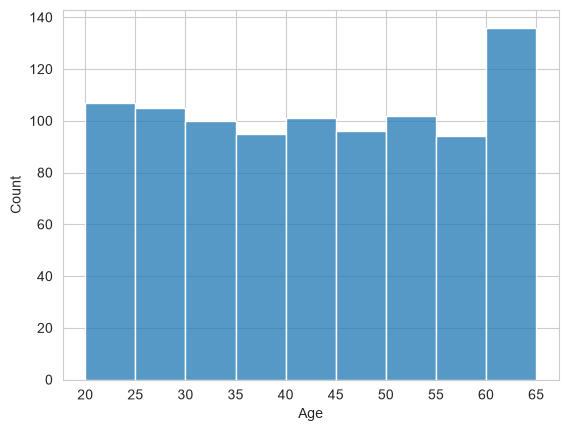

In [162]:
bins=[20,25,30,35,40,45,50,55,60,65]
sns.histplot(data=sales,x='Age',bins=bins)
plt.xticks(bins)
plt.show()

#### Which gender contributes more to sales?

In [163]:
sales.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Region,State,City,Product_Category,Product,Quantity,Unit_Price,Discount,Sales,Payment_Method,Order_Status,Salesperson,month,original_sales
0,ORD00001,2025-01-07,CUST0100,Sneha Das,Female,19.0,South,Kerala,Kochi,Electronics,Tablet,3,17844.00,0,53532.00,Debit Card,Delivered,Divya Sharma,1,53532.00
1,ORD00002,2025-11-12,CUST0188,Pooja Patel,Male,20.0,South,Kerala,Kochi,Clothing,Jeans,3,1582.58,5,4510.35,Cash,Delivered,Vijay Reddy,11,4747.74
2,ORD00003,2024-04-01,CUST0264,Naveen Patel,Female,53.0,West,Maharashtra,Pune,Groceries,Coffee,3,441.75,0,1325.25,UPI,Delivered,Ananya Sharma,4,1325.25
3,ORD00004,2024-09-26,CUST0271,Sneha Iyer,Female,57.0,West,Maharashtra,Pune,Clothing,Dress,8,2296.85,20,0.00,Cash,Cancelled,Suresh Sharma,9,18374.80
4,ORD00005,2025-06-04,CUST0129,Neha Das,Male,28.0,West,Goa,Panaji,Furniture,Sofa,3,26996.48,5,76939.97,UPI,Delivered,Sneha Patel,6,80989.44


Gender
Female    12609825.85
Male      15106634.93
Name: Sales, dtype: float64
Male
15106634.93


<Axes: xlabel='Gender'>

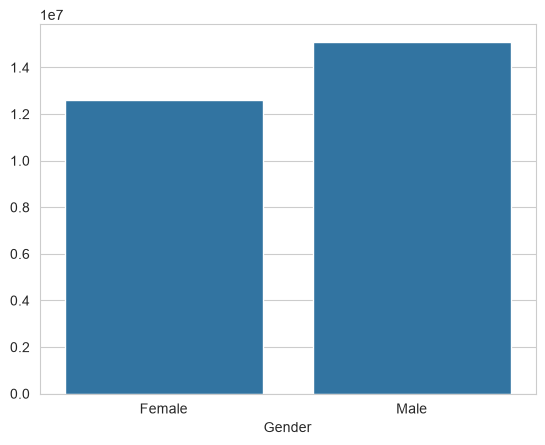

In [164]:
gender_contributes=sales.groupby('Gender')['Sales'].sum()
most_gender_type=gender_contributes.idxmax()
most_gender_sales=gender_contributes.max()
print(gender_contributes)
print(most_gender_type)
print(most_gender_sales)
sns.barplot(x=gender_contributes.index,y=gender_contributes.values)


#### Which salesperson has the highest sales?

In [165]:
sales.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Region,State,City,Product_Category,Product,Quantity,Unit_Price,Discount,Sales,Payment_Method,Order_Status,Salesperson,month,original_sales
0,ORD00001,2025-01-07,CUST0100,Sneha Das,Female,19.0,South,Kerala,Kochi,Electronics,Tablet,3,17844.00,0,53532.00,Debit Card,Delivered,Divya Sharma,1,53532.00
1,ORD00002,2025-11-12,CUST0188,Pooja Patel,Male,20.0,South,Kerala,Kochi,Clothing,Jeans,3,1582.58,5,4510.35,Cash,Delivered,Vijay Reddy,11,4747.74
2,ORD00003,2024-04-01,CUST0264,Naveen Patel,Female,53.0,West,Maharashtra,Pune,Groceries,Coffee,3,441.75,0,1325.25,UPI,Delivered,Ananya Sharma,4,1325.25
3,ORD00004,2024-09-26,CUST0271,Sneha Iyer,Female,57.0,West,Maharashtra,Pune,Clothing,Dress,8,2296.85,20,0.00,Cash,Cancelled,Suresh Sharma,9,18374.80
4,ORD00005,2025-06-04,CUST0129,Neha Das,Male,28.0,West,Goa,Panaji,Furniture,Sofa,3,26996.48,5,76939.97,UPI,Delivered,Sneha Patel,6,80989.44


Salesperson
Vikram Singh     120648.25
Vikram Sharma     54951.19
Vikram Reddy      24603.20
Vikram Rao       146210.90
Vikram Patel      44744.21
Vikram Nair      109179.15
Vikram Kumar      58467.87
Vikram Iyer       88913.73
Vikram Gupta     104331.44
Vikram Das        36631.01
Name: Sales, dtype: float64
Vikram Rao
146210.9


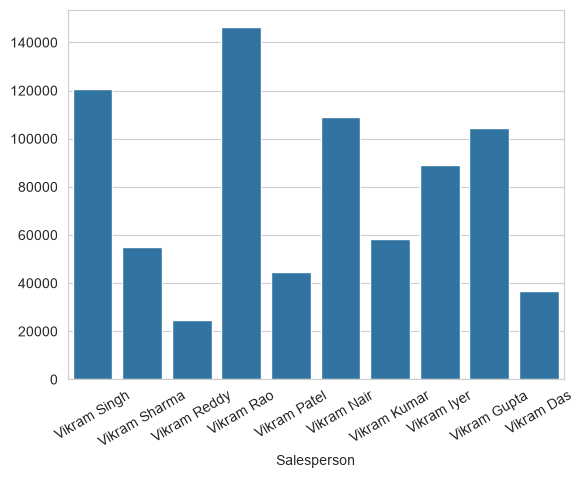

In [174]:
sales_person=sales.groupby('Salesperson')['Sales'].sum().sort_index(ascending=False).head(10)
high_sales_person=sales_person.idxmax()
high_sales_value=sales_person.max()
print(sales_person)
print(high_sales_person)
print(high_sales_value)
sns.barplot(x=sales_person.index,y=sales_person.values)
plt.xticks(rotation=30)
plt.show()


#### What percentage of orders are cancelled/returned?

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Region,State,City,Product_Category,Product,Quantity,Unit_Price,Discount,Sales,Payment_Method,Order_Status,Salesperson,month,original_sales
0,ORD00001,2025-01-07,CUST0100,Sneha Das,Female,19.0,South,Kerala,Kochi,Electronics,Tablet,3,17844.00,0,53532.00,Debit Card,Delivered,Divya Sharma,1,53532.00
1,ORD00002,2025-11-12,CUST0188,Pooja Patel,Male,20.0,South,Kerala,Kochi,Clothing,Jeans,3,1582.58,5,4510.35,Cash,Delivered,Vijay Reddy,11,4747.74
2,ORD00003,2024-04-01,CUST0264,Naveen Patel,Female,53.0,West,Maharashtra,Pune,Groceries,Coffee,3,441.75,0,1325.25,UPI,Delivered,Ananya Sharma,4,1325.25
3,ORD00004,2024-09-26,CUST0271,Sneha Iyer,Female,57.0,West,Maharashtra,Pune,Clothing,Dress,8,2296.85,20,0.00,Cash,Cancelled,Suresh Sharma,9,18374.80
4,ORD00005,2025-06-04,CUST0129,Neha Das,Male,28.0,West,Goa,Panaji,Furniture,Sofa,3,26996.48,5,76939.97,UPI,Delivered,Sneha Patel,6,80989.44
5,ORD00006,2024-02-17,CUST0062,Karthik Patel,Female,39.0,North,Rajasthan,Jaipur,Electronics,Smartphone,1,29626.70,10,26664.03,Net Banking,Delivered,Arun Patel,2,29626.70
6,ORD00007,2024-01-15,CUST0042,Suresh Patel,Male,56.0,South,Andhra Pradesh,Vijayawada,Home Appliances,Water Purifier,3,14606.97,10,39438.82,Credit Card,Delivered,Ananya Reddy,1,43820.91
7,ORD00008,2025-07-31,CUST0170,Suresh Gupta,Male,45.0,South,Kerala,Kochi,Clothing,Dress,1,2051.10,5,1948.54,Cash,Delivered,Neha Singh,7,2051.10
8,ORD00009,2025-09-24,CUST0116,Suresh Gupta,Male,23.0,East,Bihar,Patna,Furniture,Sofa,2,29822.59,5,56662.92,Credit Card,Delivered,Ravi Reddy,9,59645.18
9,ORD00010,2025-05-11,CUST0052,Neha Iyer,Male,54.0,North,Uttar Pradesh,Lucknow,Furniture,Bookshelf,2,5516.54,15,9378.12,UPI,Delivered,Vikram Kumar,5,11033.08
